# 1000-cell grid run

This notebook runs the VAMPS 1D soil solver in parallel over a **25 × 40 grid** (1 000 cells).
Each cell receives a spatially varied precipitation field; all other forcing variables
(radiation, humidity, temperature, wind) are taken unchanged from the fiji example.

The soil profile and canopy configuration are the same for every cell (fiji defaults).

**API used:**
```
Model.run_grid(forcing_grid, nworkers=N)
```
Internally this uses `multiprocessing` with POSIX shared memory:
- Forcing is packed once into shared memory — workers read column slices without copying.
- Each worker runs `soil_init → step loop` for its chunk of columns sequentially.
- Results are written back into shared memory, then copied to ordinary numpy arrays.

In [1]:
import sys, os, time, contextlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
os.environ['VAMPSLIB'] = '../share'

from vampspy.model import Model

@contextlib.contextmanager
def quiet():
    """Suppress the C solver's progress table.

    The solver writes to stderr (fd 2) via fprintf(stderr, ...).
    Redirect fd 2 to /dev/null for the duration of the block.
    Worker processes spawned inside the block inherit the suppressed fd.
    """
    sys.stderr.flush()
    devnull = os.open(os.devnull, os.O_WRONLY)
    saved   = os.dup(2)
    os.dup2(devnull, 2)
    try:
        yield
    finally:
        sys.stderr.flush()
        os.dup2(saved, 2)
        os.close(saved)
        os.close(devnull)

## 1. Load the fiji base model

In [2]:
base = Model.from_file('../examples/fiji/fiji.inp', vampslib='../share')

base.config['soil']['speed'] = 9

NY, NX = 10, 10          # grid dimensions
NCOLS   = NY * NX        # 1 000 cells
STEPS   = base.steps     # 61

print(f'Grid : {NY} × {NX} = {NCOLS} cells')
print(f'Steps: {STEPS}')
print(f'Forcing variables: {list(base.forcing.keys())}')

Grid : 10 × 10 = 100 cells
Steps: 61
Forcing variables: ['pre', 'nra', 'ira', 'rlh', 'tem', 'win']


## 2. Build spatially varied forcing

Precipitation is multiplied by a smooth spatial factor ranging from 0.5 to 1.5,
representing a realistic rainfall gradient across the grid.
All other forcing variables are uniform (identical to the fiji time series).

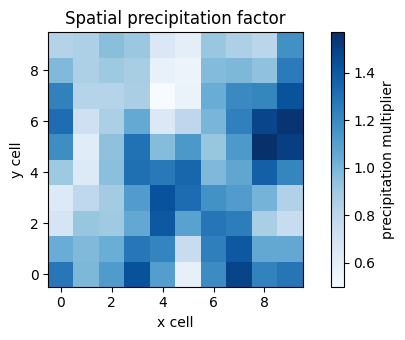

pre_factor  min=0.50  max=1.57


In [3]:
rng = np.random.default_rng(42)

# Smooth precipitation multiplier: low-frequency variation over the grid
# Interpolate a coarse random field to the full grid
coarse = rng.uniform(0.5, 1.5, size=(5, 8))
from scipy.ndimage import zoom
pre_factor = zoom(coarse, (NY / 5, NX / 8), order=3)
pre_factor = np.clip(pre_factor, 0.3, 1.8)   # ensure non-negative

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(pre_factor, cmap='Blues', origin='lower')
plt.colorbar(im, ax=ax, label='precipitation multiplier')
ax.set_title('Spatial precipitation factor')
ax.set_xlabel('x cell'); ax.set_ylabel('y cell')
plt.tight_layout()
plt.savefig('grid_pre_factor.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'pre_factor  min={pre_factor.min():.2f}  max={pre_factor.max():.2f}')

In [4]:
# Build (NY, NX, STEPS) forcing arrays
# pre: spatially varied;  all others: uniform
forcing_grid = {}

for key, ts in base.forcing.items():
    if key == 'pre':
        # (NY, NX, 1) * (STEPS,) → (NY, NX, STEPS)
        forcing_grid[key] = pre_factor[:, :, np.newaxis] * ts[np.newaxis, np.newaxis, :]
    else:
        forcing_grid[key] = np.broadcast_to(
            ts[np.newaxis, np.newaxis, :], (NY, NX, STEPS)
        ).copy()

print('Forcing shapes:')
for k, v in forcing_grid.items():
    print(f'  {k}: {v.shape}  (min={v.min():.3f}, max={v.max():.3f})')

Forcing shapes:
  pre: (10, 10, 61)  (min=0.000, max=10.261)
  nra: (10, 10, 61)  (min=14.096, max=170.289)
  ira: (10, 10, 61)  (min=27.286, max=246.087)
  rlh: (10, 10, 61)  (min=67.109, max=97.691)
  tem: (10, 10, 61)  (min=18.862, max=24.735)
  win: (10, 10, 61)  (min=0.941, max=3.885)


## 3. Run the grid

`run_grid` flattens `(NY, NX, STEPS)` → `(1000, 61)` internally, distributes
chunks across worker processes, then reshapes results back to `(NY, NX, STEPS)`.

In [5]:
NWORKERS = 4   # adjust to the number of CPU cores available

t0 = time.perf_counter()
with quiet():
    result = base.run_grid(forcing_grid, nworkers=NWORKERS)
elapsed = time.perf_counter() - t0

nlayers = result['_nlayers']

print(f'Elapsed : {elapsed:.2f} s  ({elapsed / NCOLS * 1000:.1f} ms / cell)')
print(f'Workers : {NWORKERS}')
print(f'Cells   : {NCOLS}')
print(f'Layers  : {nlayers}')
print()
print('Result shapes:')
for k, v in result.items():
    if not k.startswith('_') and hasattr(v, 'shape'):
        print(f'  {k:20s}: {v.shape}')

Elapsed : 23.59 s  (235.9 ms / cell)
Workers : 2
Cells   : 100
Layers  : 77

Result shapes:
  t                   : (10, 10, 61)
  volact              : (10, 10, 61)
  SMD                 : (10, 10, 61)
  qtop                : (10, 10, 61)
  qbot                : (10, 10, 61)
  avgtheta            : (10, 10, 61)
  cumprec             : (10, 10, 61)
  cumtra              : (10, 10, 61)
  cumeva              : (10, 10, 61)
  cumintc             : (10, 10, 61)
  masbal              : (10, 10, 61)
  precipitation       : (10, 10, 61)
  interception        : (10, 10, 61)
  transpiration       : (10, 10, 61)
  soilevaporation     : (10, 10, 61)
  theta               : (10, 10, 61, 77)
  k                   : (10, 10, 61, 77)
  h                   : (10, 10, 61, 77)
  qrot                : (10, 10, 61, 77)
  howsat              : (10, 10, 61, 77)
  q                   : (10, 10, 61, 78)
  inq                 : (10, 10, 61, 78)
  gwl                 : (10, 10, 61, 2)


## 4. Verify against single-column reference

The cell at the center of the grid where `pre_factor ≈ 1` should reproduce
the single-column `Model.run()` result closely.

In [6]:
with quiet():
    ref = base.run()

# Find the grid cell whose pre_factor is closest to 1.0
idx = np.unravel_index(np.argmin(np.abs(pre_factor - 1.0)), pre_factor.shape)
iy, ix = idx
factor_at = pre_factor[iy, ix]

print(f'Reference cell: ({iy}, {ix})  pre_factor = {factor_at:.4f}')

diff = np.max(np.abs(result['volact'][iy, ix, :] - ref['volact']))
print(f'max |volact diff| vs single-col reference: {diff:.4f} cm')
print(f'(non-zero because pre_factor = {factor_at:.4f}, not exactly 1.0)')

# A cell with identical forcing (factor=1) should match exactly
fg1 = {k: base.forcing[k][np.newaxis, :] for k in base.forcing}
with quiet():
    r1 = base.run_grid(fg1, nworkers=1)
exact_diff = np.max(np.abs(r1['volact'][0, :] - ref['volact']))
print(f'Exact match (factor=1 single cell): max |diff| = {exact_diff:.2e}')
assert exact_diff < 1e-10, 'mismatch!'
print('✓')

Reference cell: (6, 6)  pre_factor = 0.9976
max |volact diff| vs single-col reference: 0.0452 cm
(non-zero because pre_factor = 0.9976, not exactly 1.0)
Exact match (factor=1 single cell): max |diff| = 0.00e+00
✓


## 5. Spatial maps

Four maps at the end of the simulation (step 61): cumulative precipitation,
actual water volume, soil moisture deficit, and bottom flux.

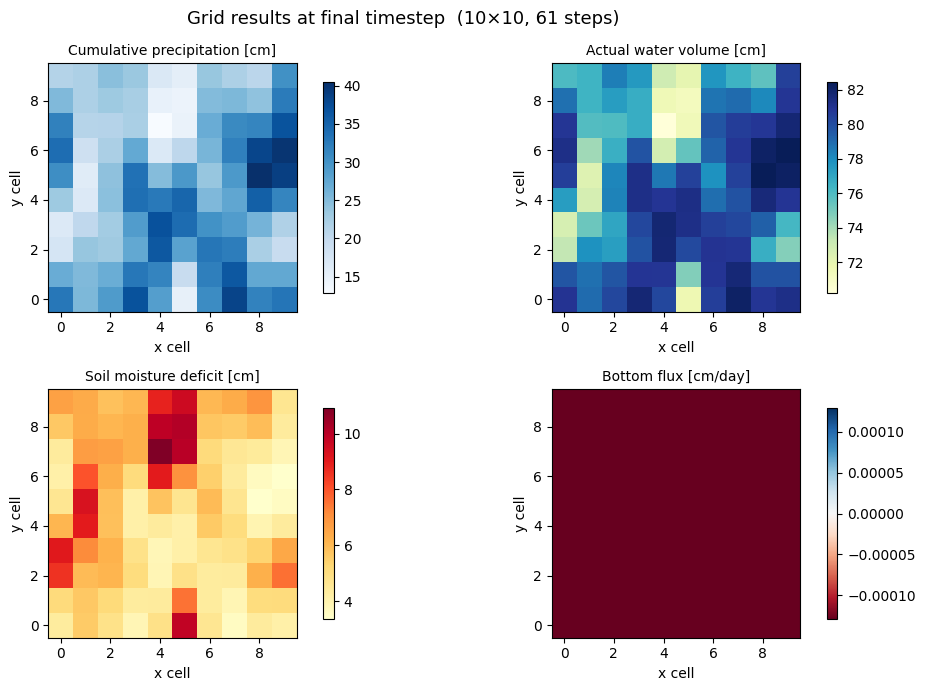

In [7]:
FINAL = -1   # last timestep

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle(f'Grid results at final timestep  ({NY}×{NX}, {STEPS} steps)', fontsize=13)

panels = [
    ('cumprec',  'Cumulative precipitation [cm]',  'Blues'),
    ('volact',   'Actual water volume [cm]',        'YlGnBu'),
    ('SMD',      'Soil moisture deficit [cm]',      'YlOrRd'),
    ('qbot',     'Bottom flux [cm/day]',             'RdBu'),
]

for ax, (key, title, cmap) in zip(axes.flat, panels):
    data = result[key][:, :, FINAL]
    vmax = np.abs(data).max() if key == 'qbot' else None
    vmin = -vmax if key == 'qbot' else None
    im = ax.imshow(data, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x cell'); ax.set_ylabel('y cell')

plt.tight_layout()
plt.savefig('grid_spatial_maps.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Time series for selected cells

Pick four cells spanning the precipitation range and compare their water-volume trajectories.

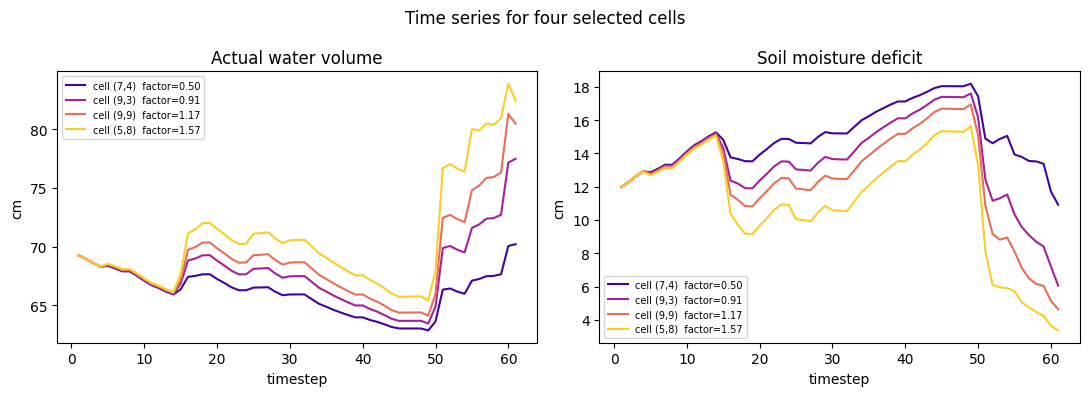

In [8]:
# Pick cells with lowest, 33rd-pct, 66th-pct and highest pre_factor
flat_idx = np.argsort(pre_factor.ravel())
pick_flat = [flat_idx[i] for i in [0, len(flat_idx)//3, 2*len(flat_idx)//3, -1]]
pick_cells = [np.unravel_index(f, (NY, NX)) for f in pick_flat]
pick_labels = [f'cell ({iy},{ix})  factor={pre_factor[iy,ix]:.2f}'
               for (iy, ix) in pick_cells]

days = np.arange(1, STEPS + 1)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Time series for four selected cells', fontsize=12)

for (iy, ix), label, color in zip(pick_cells, pick_labels, colors):
    axes[0].plot(days, result['volact'][iy, ix, :], color=color, label=label)
    axes[1].plot(days, result['SMD'][iy, ix, :],    color=color, label=label)

axes[0].set_ylabel('cm'); axes[0].set_title('Actual water volume')
axes[1].set_ylabel('cm'); axes[1].set_title('Soil moisture deficit')
for ax in axes:
    ax.set_xlabel('timestep')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Theta profiles across the grid

Depth profile of volumetric water content at the final timestep:
one line per column, coloured by cumulative precipitation.

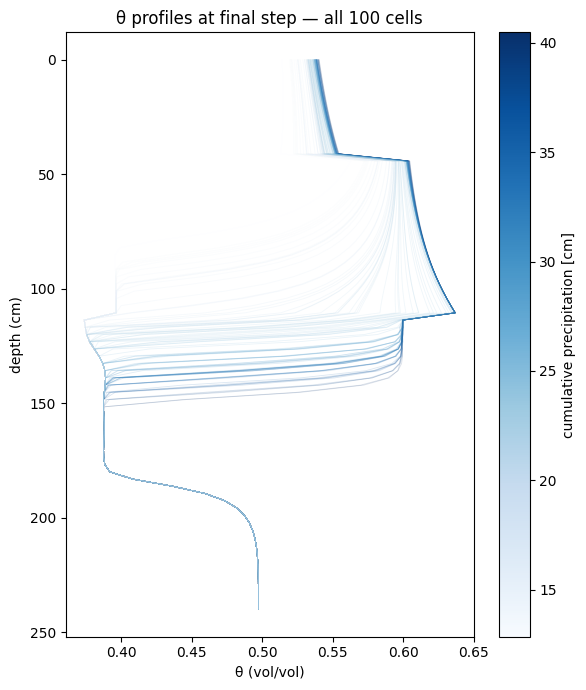

In [9]:
depth_cm = np.linspace(0, 240, nlayers)   # approximate layer mid-depths

cumprec_flat = result['cumprec'].reshape(NCOLS, STEPS)[:, FINAL]
theta_flat   = result['theta'].reshape(NCOLS, STEPS, nlayers)[:, FINAL, :]

norm = plt.Normalize(cumprec_flat.min(), cumprec_flat.max())
cmap = plt.cm.Blues

fig, ax = plt.subplots(figsize=(6, 7))
for col in range(NCOLS):
    ax.plot(theta_flat[col], depth_cm, color=cmap(norm(cumprec_flat[col])),
            alpha=0.15, linewidth=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='cumulative precipitation [cm]')
ax.invert_yaxis()
ax.set_xlabel('θ (vol/vol)')
ax.set_ylabel('depth (cm)')
ax.set_title(f'θ profiles at final step — all {NCOLS} cells')
plt.tight_layout()
plt.savefig('grid_theta_profiles.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Scaling: 1 vs 4 workers

In [10]:
timings = {}
for nw in [1, 2, 3, 4]:
    t0 = time.perf_counter()
    with quiet():
        base.run_grid(forcing_grid, nworkers=nw)
    timings[nw] = time.perf_counter() - t0
    print(f'{nw} worker(s): {timings[nw]:.2f} s  '
          f'(speedup vs 1: {timings[1]/timings[nw]:.1f}×  '
          f'{timings[nw]/NCOLS*1000:.1f} ms/cell)')

1 worker(s): 31.69 s  (speedup vs 1: 1.0×  316.9 ms/cell)
2 worker(s): 17.00 s  (speedup vs 1: 1.9×  170.0 ms/cell)
3 worker(s): 14.65 s  (speedup vs 1: 2.2×  146.5 ms/cell)
4 worker(s): 15.37 s  (speedup vs 1: 2.1×  153.7 ms/cell)
